In [1]:
%load_ext autoreload
%autoreload 2
%reset -f

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import sys
import os 

from locallib.picarrodb import *
from locallib.box import *
from locallib.query import *
from locallib.pandas import *


EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully
EU1_PROD_Conn created successfully
EU2_PROD_Conn created successfully


# Configuration Parameters

In [3]:
client = ['Cadent']
sunset_sunrise = [6, 20]
period = 'Week'
standard_utilization = {'Days':5,'Hours':6}
customer_utilization = {'Days':7,'Hours':7, "Surveyors": 25}

# Query data

## Set-up the query

In [4]:
a = get_reports('Cadent',years = [2026],table_name = "#TempReport")
b = query_emission_sources_table(report_table="#TempReport",table_name = "#TempEmissionSource")
c = query_surveys_table(report_table="#TempReport",table_name = "#TempSurvey")
d = query_segments_table(survey_table="#TempSurvey",table_name = "#TempSegment")
e = query_SurveyH3Aggregation(survey_table="#TempSurvey",table_name = "#TempSurveyH3Aggregation")
c.set_child(d)
b.set_child(c)
a.set_child(b)
data = a.execute(EU2_Conn, table_return = ["#TempReport","#TempSurvey","#TempSegment","#TempEmissionSource"])

## Process the data

In [5]:
survey_summary = pd.DataFrame()
emission_summary = pd.DataFrame()
report_summary = pd.DataFrame()

## Prepare summary main tables
#### The summaries are not dependent on date

#### Summary of Report

In [6]:
report_summary = data['#TempReport'].copy()[[
    'ReportId',
    'ReportName',
    'ReportDate',
    'ReportAssetLengthKm', 
    'AssetCoveredLengthKm', 
    'DistributionPipeKm',
    'DistributionPipeCoveredKm', 
    'DistributionPipePercentCovered', 
    'ServicePipeKm', 
    'ServicePipeCoveredKm',

]]
# Clisify (classify) the report_summary by different periods using to_period: quarter, year, month, week
#report_summary['ReportQuarter'] = pd.to_datetime(report_summary['ReportDate']).dt.isocalendar().quarter
report_summary['ReportYear'] = pd.to_datetime(report_summary['ReportDate']).dt.year
report_summary['ReportMonth'] = pd.to_datetime(report_summary['ReportDate']).dt.month
report_summary['ReportWeek'] = pd.to_datetime(report_summary['ReportDate']).dt.isocalendar().week

#### Summary of EmissionSource

In [7]:
def summarize_emission(group):
    # Remove all the rows in the group where Disposition == 2
    forCounts = group[group["Disposition"] != 2]
    forShares = group
    return pd.Series({
        "EmissionRate": forCounts["EmissionRate"].sum(),
        "LisaCount": forCounts["EmissionSourceId"].count(),
        "B0Count": forCounts["RepresentativeBinLabel"].value_counts().get("B0"),
        "B1Count": forCounts["RepresentativeBinLabel"].value_counts().get("B1"),
        "Bm1Count": forCounts["RepresentativeBinLabel"].value_counts().get("B-1"),
        "Bm2Count": forCounts["RepresentativeBinLabel"].value_counts().get("B-2"),
        "Not_NGCount": forShares["Disposition"].value_counts().get(2),
        "PGCount": forShares["Disposition"].value_counts().get(3),
        "NGCount": forShares["Disposition"].value_counts().get(1),
    })

emissions_summary = data['#TempEmissionSource'].groupby("ReportId").apply(summarize_emission)
emissions_summary.fillna(0)

,EmissionRate,LisaCount,B0Count,B1Count,Bm1Count,Bm2Count,Not_NGCount,PGCount,NGCount
ReportId,,,,,,,,,
001ADD19-39AA-8560-E44B-3A220FD10C0F,20.747008,50.0,3.0,0.0,41.0,6.0,1.0,2.0,48.0
005BC512-DA5E-6604-BCFE-3A1F6364ABEF,34.592136,36.0,9.0,0.0,25.0,2.0,1.0,7.0,29.0
007A1657-3664-172E-C2F8-3A1FCF4E6563,25.674252,50.0,7.0,0.0,38.0,5.0,27.0,6.0,44.0
007E3C3E-F141-BB09-C7D3-3A208DA42F11,22.102866,18.0,9.0,0.0,8.0,1.0,4.0,4.0,14.0
0085BBDA-DA52-9FFA-5413-3A20EA508DA6,9.502055,12.0,1.0,0.0,9.0,2.0,1.0,2.0,10.0
...,...,...,...,...,...,...,...,...,...
FF34A77E-2448-D1CE-7EF3-3A1FA0DE91D2,21.796171,25.0,9.0,0.0,13.0,3.0,2.0,5.0,20.0
FF39E6EB-0F01-B564-BFE7-3A205A1F6F44,8.202036,9.0,1.0,0.0,7.0,1.0,0.0,0.0,9.0
FF73D543-217F-292D-E5B5-3A2165EDCFC1,7.395306,13.0,3.0,0.0,10.0,0.0,11.0,6.0,7.0


#### Summary of Survey

In [8]:
sunrise = 6
sunset = 20
speed_threshold = 0.5

# Define a function to determine if survey is in 'day' or 'night'
def get_day_night(start_time, sunrise, sunset):
    # start_time should be a datetime.time object
    hour = start_time.hour
    if sunrise <= hour < sunset:
        return 'Day'
    else:
        return 'Night'

def set_actie_idle(speed, speed_threshold):
    if speed < speed_threshold:
        return 'Idle'
    else:
        return 'Active'


# Convert StartEpoch to datetime (time only, no date)
data['#TempSegment']['StartTime'] = pd.to_datetime(data['#TempSegment']['StartEpoch'], unit='s').dt.time
data['#TempSegment']['StartDate'] = pd.to_datetime(data['#TempSegment']['StartEpoch'], unit='s')
data['#TempSegment']['DayNight'] = data['#TempSegment']['StartTime'].apply(lambda t: get_day_night(t, sunrise, sunset))
data['#TempSegment']['ActiveIdle'] = data['#TempSegment']['CarSpeedMedian'].apply(lambda x: set_actie_idle(x, speed_threshold))

# Set the starting time as a datetime object
data['#TempSurvey']['StartHour'] = pd.to_datetime(data['#TempSurvey']['StartEpoch'], unit='s').dt.hour
data['#TempSurvey']['StartTime'] = pd.to_datetime(data['#TempSurvey']['StartEpoch'], unit='s').dt.time
data['#TempSurvey']['EndHour'] = pd.to_datetime(data['#TempSurvey']['EndEpoch'], unit='s').dt.hour
data['#TempSurvey']['EndTime'] = pd.to_datetime(data['#TempSurvey']['EndEpoch'], unit='s').dt.time
data['#TempSurvey']['StartDay'] = pd.to_datetime(data['#TempSurvey']['StartEpoch'], unit='s').dt.date
data['#TempSurvey']['EndDay'] = pd.to_datetime(data['#TempSurvey']['EndEpoch'], unit='s').dt.date

# Calculate the duration (in minutes) between StartEpoch and EndEpoch for each survey
data['#TempSurvey']['DurationMinutes'] = (
    data['#TempSurvey']['EndEpoch'] - data['#TempSurvey']['StartEpoch']
) / 60

def segment_summary_apply(df):
    return pd.Series({
        'DaySegments': (df['DayNight'] == 'Day').sum(),
        'NightSegments': (df['DayNight'] == 'Night').sum(),
        'ActiveSegments': (df['ActiveIdle'] == 'Active').sum(),
        'IdleSegments': (df['ActiveIdle'] == 'Idle').sum(),
        'TotalSegments': len(df),
        'TotalKilometers': df['LengthMeters'].sum() / 1000,
        'DayKilometers': df.loc[df['DayNight'] == 'Day', 'LengthMeters'].sum() / 1000,
        'NightKilometers': df.loc[df['DayNight'] == 'Night', 'LengthMeters'].sum() / 1000,
        'SegmentDurationMinutes': df['DurationSeconds'].sum() / 60,
        'IdleTimeMinutes': df.loc[df['ActiveIdle'] == 'Idle', 'DurationSeconds'].sum() / 60,
        'ActiveTimeMinutes': df.loc[df['ActiveIdle'] == 'Active', 'DurationSeconds'].sum() / 60,
        'AvgSpeedKm': 3.6*df['CarSpeedMedian'].mean()

    })

def survey_summary_apply(row):
    return pd.Series({
        'SurveyId': row['SurveyId'],
        'SurveyorUnit': row['SurveyorUnit'],
        'SurveyDurationMinutes': row['DurationMinutes'],
        'ReportId': row['ReportId'],
        'StartHour': row['StartHour'],
        'StartTime': row['StartTime'],
        'StartEpoch': row['StartEpoch'],
        'EndTime': row['EndTime'],
        'EndEpoch': row['EndEpoch'],
        'StartDay': row['StartDay'],
        'EndDay': row['EndDay'],
        'LateralRotation': row['LateralRotation'],
        'NumberOfPeaks': row['NumberOfPeaks']
    })

# Apply the function row-wise (axis=1) to build a DataFrame summary
survey_summary = data['#TempSurvey'].apply(survey_summary_apply, axis=1)
segment_summary = data['#TempSegment'].groupby("SurveyId").apply(segment_summary_apply)
survey_summary = pd.merge(survey_summary,segment_summary,on="SurveyId",how="left")


## Calculate KPI
#### KPI are dependent on time

In [9]:
aggregator = ["ReportYear","ReportWeek"]

#### FOV

In [10]:
from datetime import datetime, timedelta

def days_in_week_range(week_number, year):
    """
    Helper to count days in a week. If it's the current week, return days up to today.
    week_number: int week number (ISO, 1-53).
    year: int year.
    current_week: int, current week number.
    """
    from datetime import date, timedelta

    # Get Monday of the ISO week
    try:
        start_date = date.fromisocalendar(int(year), int(week_number), 1)
    except Exception:
        # If not a valid ISO week/year, fall back to 7
        return 7

    # End on Sunday
    end_date = start_date + timedelta(days=6)

    today = datetime.now().date()
    this_iso = today.isocalendar()[:2]  # (year, week)

    if (int(year), int(week_number)) == this_iso:
        delta = (today - start_date).days + 1  # include today
        return min(max(delta, 0), 7)
    else:
        return 7

def report_summary_apply(df):
    # For groupby logic: the grouped df will have ReportYear and ReportWeek as its group key in .name or .index
    if hasattr(df, 'name') and df.name is not None:
        group_year = df.name[0]
        group_week_range = df.name[1]
    else:
        group_year, group_week_range = None, None
    current_year = datetime.now().year
    current_week = datetime.now().isocalendar()[1]

    if group_year is not None and group_week_range is not None:

        day_count = days_in_week_range(group_week_range, current_year)
    else:
        day_count = None

    return pd.Series({
        'FOVMain': df['DistributionPipeCoveredKm'].sum()/df['DistributionPipeKm'].sum(),
        'ReportAssetLengthKm': df['ReportAssetLengthKm'].sum() if 'ReportAssetLengthKm' in df else None,
        'AssetCoveredLengthKm': df['AssetCoveredLengthKm'].sum() if 'AssetCoveredLengthKm' in df else None,
        'DistributionPipeKm': df['DistributionPipeKm'].sum() if 'DistributionPipeKm' in df else None,
        'DistributionPipeCoveredKm': df['DistributionPipeCoveredKm'].sum() if 'DistributionPipeCoveredKm' in df else None,
        'ServicePipeKm': df['ServicePipeKm'].sum() if 'ServicePipeKm' in df else None,
        'ServicePipeCoveredKm': df['ServicePipeCoveredKm'].sum() if 'ServicePipeCoveredKm' in df else None,
        'ReportCount': df.shape[0],
        'DaysCount': day_count
    })

report_by_period = report_summary.groupby(aggregator).apply(report_summary_apply)
report_by_period = report_by_period.round(2)

### Estimated POR

In [11]:
acc = report_by_period['AssetCoveredLengthKm'].cumsum()
acc = acc.fillna(0).rolling(window=3, min_periods=1).mean()
acc = acc.reset_index()
acc.drop(columns=['ReportYear'], inplace=True)  # Perform a moving (rolling) linear regression over 3-point window on cumulative AssetCoveredLengthKm
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare result series with same index as acc
moving_linreg_pred = pd.Series(index=acc.index, dtype=float)
coefficients = pd.DataFrame(index=acc.index, columns=['slope', 'intercept'], dtype=float)
window_size = 3
POR = 127000
for i in range(window_size-1, len(acc)):
    y = acc.iloc[i - window_size + 1:i + 1]['AssetCoveredLengthKm']
    x = acc.iloc[i - window_size + 1:i + 1]['ReportWeek']
    # Only fit if valid points
    if np.isfinite(y).sum() >= 2 and np.isfinite(x).sum() >= 2:
        valid = np.isfinite(y) & np.isfinite(x)
        x_valid = x[valid].values.reshape(-1, 1)
        y_valid = y[valid].values
        model = LinearRegression()
        model.fit(x_valid, y_valid)
        # Get the slope and the intercept
        slope = model.coef_[0]
        intercept = model.intercept_
        moving_linreg_pred.iloc[i] = (POR - intercept)/slope
        coefficients.loc[i, 'slope'] = slope
        coefficients.loc[i, 'intercept'] = intercept
    else:
        moving_linreg_pred.iloc[i] = np.nan
        coefficients.loc[i, 'slope'] = np.nan
        coefficients.loc[i, 'intercept'] = np.nan

# Convert number of weeks since week 1 of 2026 to expected month and year
from datetime import datetime, timedelta

def week_to_month_year(week_num):
    # Week 1 of 2026 starts at first Monday of 2026
    first_week_start = datetime.strptime('2026-01-05', '%Y-%m-%d')
    # Calculate date of that week_num's Monday
    expected_date = first_week_start + timedelta(weeks=week_num)
    return expected_date.strftime('%B %Y')

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    expected_months_years = moving_linreg_pred.apply(lambda x: week_to_month_year(int(x)) if pd.notnull(x) else np.nan)


expected_months_years

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:956: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(
/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:956: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(
/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:956: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please c

0               NaN
1               NaN
2         June 2046
3     February 2038
4      January 2033
5      January 2030
6       August 2028
7     December 2027
8      October 2027
9     November 2027
10    December 2027
11    December 2027
12        July 2027
13         May 2027
14       March 2027
15    February 2027
16     January 2027
17    December 2026
18    November 2026
19    December 2026
20    December 2026
21    December 2026
22    December 2026
23    December 2026
24    December 2026
25     January 2027
26    February 2027
dtype: object

In [12]:
acc = report_by_period['AssetCoveredLengthKm'].cumsum()
acc = acc.reset_index()
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare result series with same index as acc
moving_linreg_pred = pd.Series(index=acc.index, dtype=float)
coefficients = pd.DataFrame(index=acc.index, columns=['slope', 'intercept'], dtype=float)
window_size = 4
POR = 127000
for i in range(window_size-1, len(acc)):
    y = acc.iloc[i - window_size + 1:i + 1]['AssetCoveredLengthKm']
    x = acc.iloc[i - window_size + 1:i + 1]['ReportWeek']
    # Only fit if valid points
    if np.isfinite(y).sum() >= 2 and np.isfinite(x).sum() >= 2:
        valid = np.isfinite(y) & np.isfinite(x)
        x_valid = x[valid].values.reshape(-1, 1)
        y_valid = y[valid].values
        model = LinearRegression()
        model.fit(x_valid, y_valid)
        # Get the slope and the intercept
        slope = model.coef_[0]
        intercept = model.intercept_
        moving_linreg_pred.iloc[i] = (POR - intercept)/slope
        coefficients.loc[i, 'slope'] = slope
        coefficients.loc[i, 'intercept'] = intercept
    else:
        moving_linreg_pred.iloc[i] = np.nan
        coefficients.loc[i, 'slope'] = np.nan
        coefficients.loc[i, 'intercept'] = np.nan

# Convert number of weeks since week 1 of 2026 to expected month and year
from datetime import datetime, timedelta

def week_to_month_year(week_num):
    # Week 1 of 2026 starts at first Monday of 2026
    first_week_start = datetime.strptime('2026-01-05', '%Y-%m-%d')
    # Calculate date of that week_num's Monday
    expected_date = first_week_start + timedelta(weeks=week_num)
    return expected_date.strftime('%B %Y')

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    expected_months_years = moving_linreg_pred.apply(lambda x: week_to_month_year(int(x)) if pd.notnull(x) else np.nan)


acc['ExpectedCompletion'] = expected_months_years.values

# Regroup using ReportYear and ReportWeek, call this variable POR
POR = acc.groupby(['ReportYear', 'ReportWeek']).first().copy()


/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:956: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(
/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:956: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(
/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:956: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please c

#### Plot of the POR

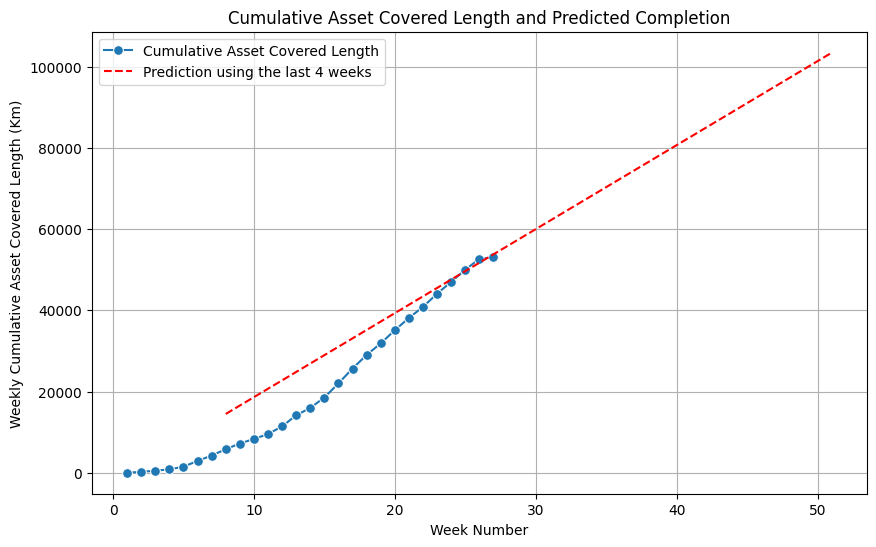

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot the cumulative Asset Covered Length using seaborn
sns.lineplot(
    x=acc['ReportWeek'],
    y=acc['AssetCoveredLengthKm'],
    marker='o',
    markersize=7,
    label='Cumulative Asset Covered Length'
)

# Plot the regression line using the last set of coefficients (last valid slope and intercept)
last_valid_idx = coefficients['slope'].last_valid_index()
if pd.notnull(coefficients.loc[last_valid_idx, 'slope']) and pd.notnull(coefficients.loc[last_valid_idx, 'intercept']):
    slope = coefficients.loc[last_valid_idx, 'slope']
    intercept = coefficients.loc[last_valid_idx, 'intercept']
    x_vals = np.arange(8, 52, 1)
    y_vals = slope * x_vals + intercept
    # For regression line, use sns.lineplot, but without markers
    sns.lineplot(
        x=x_vals,
        y=y_vals,
        color='r',
        linestyle='--',
        label='Prediction using the last 4 weeks'
    )

plt.xlabel('Week Number')
plt.ylabel('Weekly Cumulative Asset Covered Length (Km)')
plt.title('Cumulative Asset Covered Length and Predicted Completion')
plt.legend()
plt.grid(True)


### Utilization, Productivity, Surveys per day / car, Idle time, Avg Speeds and Night Surveys

In [14]:
def report_KPI_apply(df):
    if hasattr(df, 'name') and df.name is not None:
        group_year = df.name[0]
        group_week_range = df.name[1]
    else:
        group_year, group_week_range = None, None
    current_year = datetime.now().year

    current_week = datetime.now().isocalendar()[1]
    if group_year is not None and group_week_range is not None:
        day_count = days_in_week_range(group_week_range, current_year)
    else:
        day_count = None
    
    unique_reports = df.drop_duplicates(subset=['ReportId'])
    no_surveyors = df['SurveyorUnit'].nunique()
    surveyDurationHours = df['SurveyDurationMinutes'].sum()/60
    targetTimeHours = day_count*customer_utilization['Hours']*no_surveyors
    starndardTargetTimeHours = 6*5*25
    #targetTimeHours = 7*7*25
    surveyCount = df['SurveyId'].nunique()
    avg_speed_weighted = df['AvgSpeedKm'] * df['TotalSegments']

    return pd.Series({
        'SurveyDurationHours': surveyDurationHours,
        'TargetDurationHours': targetTimeHours,
        'CustomerUtilization': surveyDurationHours/targetTimeHours,
        'StarndardUtilization': surveyDurationHours/starndardTargetTimeHours,
        'TotalSurveyors': no_surveyors,
        'ProductivityPerSurveyor': unique_reports['DistributionPipeCoveredKm'].sum()/no_surveyors,
        'SurveyCount': surveyCount,
        'AvgSpeedKm': avg_speed_weighted.sum()/df['TotalSegments'].sum(),
        'SurveysCarDay': surveyCount/no_surveyors/day_count,
        'IdleTime': 100*df['IdleTimeMinutes'].sum()/df['SurveyDurationMinutes'].sum(),
        'DaysCount': day_count,
        'TotalDrivenLengthKm': df['TotalKilometers'].sum(),
        'DrivingRatio': df['TotalKilometers'].sum()/unique_reports['AssetCoveredLengthKm'].sum(),
        'NightDrivenLength': df['NightKilometers'].sum(),
        'DayDrivenLength': df['DayKilometers'].sum(),
        'NightRatio': 100*df['NightKilometers'].sum()/df['TotalKilometers'].sum(),
        'DayRatio': 100*df['DayKilometers'].sum()/df['TotalKilometers'].sum(),
    })
report_summary_agg = pd.merge(report_summary,survey_summary,on='ReportId',how="left")
report_KPI_df = report_summary_agg.groupby(aggregator).apply(report_KPI_apply)
report_KPI_df = report_KPI_df.drop(columns=["DaysCount"]).round(2)

### Instantaneous Emissions and Lisa densities

In [15]:
emission_by_report = pd.merge(report_summary,emissions_summary,on="ReportId",how="left")

denominator = 'DistributionPipeCoveredKm'

def quarter_density_share_apply(df):
    out = {}
    denom = df[denominator].sum()
    lisa_count = df["LisaCount"].sum()
    out["LisaCount"] = lisa_count
    out["EmissionRate"] = df["EmissionRate"].sum()
    out["B0Count"] = df["B0Count"].sum()
    out["B1Count"] = df["B1Count"].sum()
    out["Bm1Count"] = df["Bm1Count"].sum()
    out["Bm2Count"] = df["Bm2Count"].sum()
    out["NGCount"] = df["NGCount"].sum()
    out["PGCount"] = df["PGCount"].sum()
    out["Not_NGCount"] = df["Not_NGCount"].sum()

    out["LisaDensity"] = lisa_count / denom if denom else None
    out["InstatanoeusEmission"] = out["EmissionRate"] / denom if denom else None
    out["B0Density"] = out["B0Count"] / denom if denom else None
    out["B1Density"] = out["B1Count"] / denom if denom else None
    out["B-1Density"] = out["Bm1Count"] / denom if denom else None
    out["B-2Density"] = out["Bm2Count"] / denom if denom else None
    out["NGDensity"] = out["NGCount"] / denom if denom else None
    out["PGDensity"] = out["PGCount"] / denom if denom else None

    total_sum = out['NGCount'] + out['Not_NGCount'] + out['PGCount']

    out["B0Share"] = out["B0Count"] / lisa_count if lisa_count else None
    out["B1Share"] = out["B1Count"] / lisa_count if lisa_count else None
    out["B-1Share"] = out["Bm1Count"] / lisa_count if lisa_count else None
    out["B-2Share"] = out["Bm2Count"] / lisa_count if lisa_count else None
    out["NGShare"] = out["NGCount"] / total_sum if total_sum else None
    out["PGShare"] = out["PGCount"] / total_sum if total_sum else None
    out["Not_NGShare"] = out["Not_NGCount"] / total_sum if total_sum else None

    return pd.Series(out)

emission_by_report_quarter = emission_by_report.groupby(aggregator).apply(quarter_density_share_apply)
emission_by_report_quarter = emission_by_report_quarter.round(2)
emission_by_report_quarter


LisaCount  EmissionRate  B0Count  B1Count  Bm1Count  \
ReportYear ReportWeek                                                        
2026       1                91.0         66.94     21.0      0.0      67.0   
           2               230.0        294.88     66.0      2.0     150.0   
           3               302.0        509.71    116.0      8.0     166.0   
           4               345.0        322.13     83.0      2.0     239.0   
           5               532.0        494.87    118.0      4.0     366.0   
           6              1556.0       1637.43    408.0     16.0    1006.0   
           7              1393.0       1294.56    295.0      8.0     956.0   
           8              1384.0       1325.76    353.0      7.0     909.0   
           9              1295.0       1292.14    313.0     12.0     849.0   
           10             1298.0       1653.28    219.0     27.0     886.0   
           11             1348.0       1625.15    259.0     12.0     945.0   
           12             2347.0       1886.40    425.0     13.0    1592.0   
           13             2808.0       2533.81    556.0     26.0    1901.0   
           14             1867.0       1502.01    354.0      7.0    1291.0   
           15             3359.0       3441.57    688.0     30.0    2281.0   
           16             4210.0       4334.03    910.0     46.0    2862.0   
           17             4194.0       4307.92    773.0     38.0    2942.0   
           18             4553.0       4895.25    946.0     57.0    3158.0   
           19             4252.0       4613.79    820.0     59.0    2979.0   
           20             4815.0       4426.17    871.0     44.0    3344.0   
           21             4100.0       4538.81    872.0     40.0    2746.0   
           22             4275.0       5229.29    963.0     63.0    2846.0   
           23             3498.0       5423.78    854.0     83.0    2258.0   
           24             3232.0       3760.74    677.0     61.0    2184.0   
           25             4544.0       5048.72    900.0     42.0    3152.0   
           26             4091.0       5184.61    773.0     60.0    2857.0   
           27              300.0        271.07     55.0      3.0     219.0   

                       Bm2Count  NGCount  PGCount  Not_NGCount  LisaDensity  \
ReportYear ReportWeek                                                         
2026       1                3.0     72.0     19.0          7.0         1.93   
           2               12.0    173.0     57.0         26.0         1.08   
           3               12.0    241.0     61.0         26.0         1.09   
           4               21.0    267.0     78.0         27.0         1.09   
           5               44.0    373.0    159.0         59.0         0.81   
           6              126.0   1184.0    372.0        167.0         1.12   
           7              134.0   1084.0    309.0        147.0         1.07   
           8              115.0   1078.0    306.0         90.0         0.90   
           9              121.0   1058.0    237.0        113.0         0.95   
           10             166.0   1076.0    222.0        197.0         1.16   
           11             132.0   1145.0    203.0        102.0         1.16   
           12             317.0   1970.0    377.0        297.0         1.25   
           13             325.0   2352.0    456.0        321.0         1.06   
           14             215.0   1522.0    345.0        158.0         1.04   
           15             360.0   2997.0    362.0        224.0         1.35   
           16             392.0   3820.0    390.0        235.0         1.23   
           17             441.0   3729.0    465.0        520.0         1.18   
           18             392.0   4111.0    442.0        375.0         1.39   
           19             394.0   3809.0    443.0        472.0         1.53   
           20             556.0   4314.0    501.0        419.0         1.52   
           21         

#### Peaks above SAT

In [16]:
box_peak_sat = BoxFile(local_path = "peak_SAT.xlsx", box_file_id = 2206415797785)
box_peak_sat.download()
peak_sat = pd.read_excel("peak_SAT.xlsx", engine="openpyxl")
box_peak_sat.delete()
# Add ReportYear and ReportWeek using isocalendar for robust extraction
peak_sat['Date'] = pd.to_datetime(peak_sat['Date'], errors='coerce')
peak_sat['ReportYear'] = peak_sat['Date'].dt.isocalendar().year
peak_sat['ReportWeek'] = peak_sat['Date'].dt.isocalendar().week

week_peak_sat = peak_sat.groupby(['ReportYear', 'ReportWeek']).agg({"PeakId": "count"})
week_peak_sat.rename(columns={"PeakId": "PeakAboveSATCount"}, inplace=True)

/home/sandbox/personal-repos/packages/locallib/box/BoxFile.py:17: UserWarning: The file peak_SAT.xlsx does not exist locally
  warnings.warn(f'The file {self.local_path.as_posix()} does not exist locally')


# Write the files to excel

In [17]:
# Format
# Colunm name, Unit, Description, Formula used to calculate the value
output_dict={
    'ReportWeek' : ['', 'Number of the week starting from 2026-01-01', ''],
    'ReportAssetLengthKm': ['Km', 'Total length of all the assets in the specified period', ''],
    'AssetCoveredLengthKm': ['Km', 'Total length of all the assets covered in the report', ''],
    'DistributionPipeKm': ['Km', 'Total length of all the mains in the report', ''],
    'DistributionPipeCoveredKm': ['Km', 'Total length of all the mains covered in the report', ''],
    'ServicePipeKm': ['Km', 'Total length of all the services in the report', ''],
    'ServicePipeCoveredKm': ['Km', 'Total length of all the services covered in the report', ''],
    'ReportCount': ['Report', 'Total number of reports in the specified week', ''],
    'DaysCount': ['Day', 'Total number of days worked in the specified week', ''],
    'FOVMain': ['Percent', 'Km of mains covered over the total Km of mains', 'DistributionPipeCoveredKm / DistributionPipeKm'],
    'SurveyDurationHours': ['Hours', 'Total hours driven by all cars in the week', ''],
    'TargetDurationHours': ['Hours', 'Exepected total number hours driven by all cars available. i.e 7 days * 7 hours * 25 cars', ''],
    'CustomerUtilization': ['Percent', 'Total hours driven by all cars in the week over the expected total number hours driven by all cars available. i.e 7 days * 7 hours * 25 cars', 'SurveyDurationHours / TargetDurationHours'],
    'StarndardUtilization': ['Percent', 'Total hours driven by all cars in the week over the expected total number hours driven by all cars available. i.e 6 days * 5 hours * 25 cars', 'SurveyDurationHours / TargetDurationHours'],
    'TotalSurveyors': ['Surveyor', 'Total number of surveyors in the specified week', ''],
    'ProductivityPerSurveyor': ['Km / Surveyor', 'Total length of all the assets covered in the report over the total number of surveyors in the specified week', 'DistributionPipeCoveredKm / TotalSurveyors'],
    'SurveyCount': ['Survey', 'Total number of surveys in the  specified week', ''],
    'AvgSpeedKm': ['Km/h', 'Average speed counting all the cars in the specified week', ''],
    'SurveysCarDay': ['Survey / Car / Day', 'Total number of surveys per car per day in the specified week', 'SurveyCount / TotalSurveyors / DaysCount'],
    'IdleTime': ['Percent', 'Ratio of idle time over the total survey duration', 'IdleTimeMinutes / SurveyDurationMinutes'],
    'TotalDrivenLengthKm': ['Km', 'Total length driven in the specified week', ''],
    'DrivingRatio': ['Ratio', 'Total length driven in the specified week over Total length of all the assets covered in the report', 'TotalKilometers / DistributionPipeCoveredKm'],
    'NightDrivenLength': ['Km', 'Total length covered during the night in the specified week', ''],
    'DayDrivenLength': ['Km', 'Total length covered during the day in the specified week', ''],
    'NightRatio': ['Ratio', 'NightKm / TotalKilometers', ''],
    'DayRatio': ['Ratio', 'DayKm / TotalKilometers', ''],
    'PeakAboveSATCount': ['Peak', 'Total number of peaks above SAT in the specified week', ''],
    'LisaCount': ['Lisa', 'Total number of Lisa in the specified week, (No Disposition 2)', ''],
    'EmissionRate': ['SCFH', 'Total emission rate in the specified week, (No Disposition 2)', ''],
    'B0Count': ['Lisa', 'Total number of B0 in the specified week, (No Disposition 2)', ''],
    'B1Count': ['Lisa', 'Total number of B1 in the specified week, (No Disposition 2)', ''],
    'Bm1Count': ['Lisa', 'Total number of B-1 in the specified week, (No Disposition 2)', ''],
    'Bm2Count': ['Lisa', 'Total number of B-2 in the specified week, (No Disposition 2)', ''],
    'NGCount': ['Lisa', 'Total number of NG in the specified week, (With Disposition 2)', ''],
    'PGCount': ['Lisa', 'Total number of PG in the specified week, (With Disposition 2)', ''],
    'Not_NGCount': ['Lisa', 'Total number of Not NG in the specified week, (With Disposition 2)', ''],
    'LisaDensity': ['Lisa / Km', 'Number of Lisa per Km of Asset Covered', 'LisaCount / DistributionPipeCoveredKm'],
    'InstatanoeusEmission': ['SCFH / Km', 'Emission rate per Km of Asset Covered', 'EmissionRate / DistributionPipeCoveredKm'],
    'B0Density': ['Lisa / Km', 'Number of B0 per Km of Asset Covered', 'B0Count / DistributionPipeCoveredKm'],
    'B1Density': ['Lisa / Km', 'Number of B1 per Km of Asset Covered', 'B1Count / DistributionPipeCoveredKm'],
    'B-1Density': ['Lisa / Km', 'Number of B-1 per Km of Asset Covered', 'Bm1Count / DistributionPipeCoveredKm'],
    'B-2Density': ['Lisa / Km', 'Number of B-2 per Km of Asset Covered', 'Bm2Count / DistributionPipeCoveredKm'],
    'B0Share': ['Percent', 'Number of B0 per Lisa', 'B0Count / LisaCount'],
    'B1Share': ['Percent', 'Number of B1 per Lisa', 'B1Count / LisaCount'],
    'B-1Share': ['Percent', 'Number of B-1 per Lisa', 'Bm1Count / LisaCount'],
    'B-2Share': ['Percent', 'Number of B-2 per Lisa', 'Bm2Count / LisaCount'],
    'NGShare': ['Percent', 'Number of NG per Lisa', 'NGCount / (NGCount + Not_NGCount + PGCount)'],
    'PGShare': ['Percent', 'Number of PG per Lisa', 'PGCount / (NGCount + Not_NGCount + PGCount)'],
    'Not_NGShare': ['Percent', 'Number of Not NG per Lisa', 'Not_NGCount / (NGCount + Not_NGCount + PGCount)'],
    'ExpectedCompletion': ['Date', 'Expected completion predction by regression based on the data of last month', ''],
}

# Write Excel

In [35]:
def week_dates(year, week):
    """
    Returns the start and end dates (Monday to Sunday) of the given ISO week and year.
    """
    # Ensure year and week are integers (convert if they're not)
    year = int(year)
    week = int(week)
    # Use the ISO calendar to get the Monday of the week
    # ISO: Monday is 1, Sunday is 7
    from datetime import date, timedelta
    # Python 3.8+ provides fromisocalendar
    week_start = date.fromisocalendar(year, week, 1)
    week_end = week_start + timedelta(days=6)
    # Make sure week_start is not before 2026-01-01
    min_start = date(2026, 1, 1)
    if week_start < min_start:
        week_start = min_start
        week_end = week_start + timedelta(days=6)
    return week_start, week_end

from functools import reduce

dfs_to_merge = [report_by_period, report_KPI_df, emission_by_report_quarter, POR, week_peak_sat]

# We'll merge on 'aggregator', using left joins throughout
merged_emission_kpi = reduce(
    lambda left, right: pd.merge(left, right, on=aggregator, how="left", suffixes=('', '_dup')),
    dfs_to_merge
)
# Remove any columns created by conflicting names with '_dup' suffix
merged_emission_kpi = merged_emission_kpi.loc[:, ~merged_emission_kpi.columns.str.endswith('_dup')]

# Only keep columns that are keys in output_dict
columns_to_export = [col for col in output_dict.keys() if col in merged_emission_kpi.columns]
# The 'units' list contains the first item (unit) from the value list of output_dict for each exported column
units = [output_dict[col][0] if col in output_dict and isinstance(output_dict[col], list) and len(output_dict[col]) > 0 else "" for col in columns_to_export]

export_df = merged_emission_kpi[columns_to_export]

#Arrangement of the columns
export_df = export_df.reset_index()
export_df["WeekDates"] = export_df["ReportWeek"].apply(
    lambda week: f"{week_dates(2026, int(week))[0]} to {week_dates(2026, int(week))[1]}"
)

export_df.drop(columns=["ReportYear"],inplace=True)
units = ["", ""] + units  # Add two zeros (empty string placeholders) at the beginning


# Move "WeekDates" to the second column in export_df
cols = list(export_df.columns)
if "WeekDates" in cols:
    cols.insert(1, cols.pop(cols.index("WeekDates")))
    export_df = export_df[cols]


with pd.ExcelWriter("output/Cadent_E_KPI.xlsx") as writer:
    # Write the filtered DataFrame to the first sheet
    # Write columns and units as first two rows, then export the rest of the DataFrame
    columns_and_units = [export_df.columns.tolist(), units]
    rows = export_df.values.tolist()
    full_rows = [export_df.columns.tolist(), units] + rows
    temp_df = pd.DataFrame(full_rows)
    temp_df.to_excel(writer, sheet_name="KPI 2026 Weekly", index=False, header=False)

    # Post-process the sheet for bold and center alignment of the first two columns
    worksheet = writer.sheets["KPI 2026 Weekly"]
    # Create bold and center formats
    bold_center = writer.book.add_format({'bold': True, 'align': 'center'})
    center = writer.book.add_format({'align': 'center'})

    # The first two rows (headers and units): apply bold and center format to *all* columns, not just columns 0 and 1
    for row_idx in range(2):
        for col_idx in range(len(full_rows[row_idx])):
            worksheet.write(row_idx, col_idx, full_rows[row_idx][col_idx], bold_center)  # overwrite with bold+center

    # All other rows: just center the first two columns
    for i, row in enumerate(rows, start=2):
        for col in range(2):
            worksheet.write(i, col, row[col], center)
    # Add a colored line (cell border) at the bottom of all cells in the second row (units row)
    bottom_border_format = writer.book.add_format({'bottom': 1, 'bottom_color': '#000000', 'align': 'center', 'bold': True})
    for col_idx in range(len(full_rows[1])):
        worksheet.write(1, col_idx, full_rows[1][col_idx], bottom_border_format)
    

    # Write the key and its list of [Unit, Description, Formula Used] as columns in the second sheet
    desc_rows = []
    for key, value in output_dict.items():
        if isinstance(value, list) and len(value) == 3:
            # Value is a list: [Unit, Description, Formula Used]
            row = [key] + value
        else:
            # Fallback in case the dictionary isn't formatted as expected
            row = [key, "", "", ""]
        desc_rows.append(row)
    columns = ["Key", "Unit", "Description", "Formula Used"]
    desc_df = pd.DataFrame(desc_rows, columns=columns)
    desc_df.to_excel(writer, sheet_name="KPI Descriptions", index=False)

    # Adjust the column widths for better readability in both sheets
    workbook  = writer.book
    for sheet_name, df in [("KPI 2026 Weekly", export_df), ("KPI Descriptions", desc_df)]:
        worksheet = writer.sheets[sheet_name]
        for i, col in enumerate(df.columns):
            # Find max length in the column plus the column header
            max_len = max(
                df[col].astype(str).map(len).max(),
                len(col)
            ) + 2
            # Set the column width (Excel columns are 0-indexed)
            worksheet.set_column(i, i, max_len)

In [36]:
box_obj = BoxFile(local_path = 'output/Cadent_E_KPI.xlsx', box_file_id = 2266637913401)
box_obj.upload()

# Plot KPI

# Calculate distributions

#### Breadcrumbs per segment of street

To be done

#### Distribution of survey duration
##### Compute

In [20]:

# Categorize the surveys by 'night date'

# We'll define a 'night date' as the date the survey starts if it starts before noon;
# otherwise, the 'night date' is the next calendar day. This is sometimes used to attribute
# overnight surveys to the nocturnal period in which most of the survey was conducted.
# Adjust as needed for your definition of "night".

def setAnalysisDate(row):
    if (row['StartHour'] >= 0) & (row['StartHour'] < 7):
        return (row['StartDay'] - pd.Timedelta(days=1))
    else:
       return row['StartDay']

# Ensure 'StartDay' is in datetime format before using .dt accessor
shift_calc = report_summary_agg.copy()
if not np.issubdtype(shift_calc['StartDay'].dtype, np.datetime64):
    shift_calc['StartDay'] = pd.to_datetime(shift_calc['StartDay'], errors='coerce')

shift_calc = shift_calc[shift_calc['StartDay'].dt.year == 2026].copy()
shift_calc["AnalysisDate"] = shift_calc.apply(setAnalysisDate, axis=1)
# Get the earliest StartTime for each (AnalysisDate, SurveyorUnit) group
time_boundary = shift_calc.groupby(["AnalysisDate", "SurveyorUnit"]).agg({"StartEpoch": "min", "EndEpoch": "max"})

# Assign AnalysisDate to a week (e.g., using pandas Period or custom logic)
# We'll make a new column "AnalysisWeek" for each (AnalysisDate, SurveyorUnit)
time_boundary = time_boundary.reset_index()
time_boundary['Week'] = pd.to_datetime(time_boundary['AnalysisDate']).dt.isocalendar().week
# Convert StartEpoch and EndEpoch to 'HH:MM' format (string)
time_boundary['StartHour'] = pd.to_datetime(time_boundary['StartEpoch'], unit='s').dt.hour
time_boundary['EndHour'] = pd.to_datetime(time_boundary['EndEpoch'], unit='s').dt.hour
time_boundary.reset_index(drop=True)

,AnalysisDate,SurveyorUnit,StartEpoch,EndEpoch,Week,StartHour,EndHour
0,2026-01-04,Cadent Surveyor #01 - LO75ZDT,1.767561e+09,1.767579e+09,1,21,2
1,2026-01-05,Cadent Surveyor #01 - LO75ZDT,1.767652e+09,1.767665e+09,2,22,2
2,2026-01-05,Cadent Surveyor #02 - LO75TNZ,1.767646e+09,1.767661e+09,2,20,0
3,2026-01-05,Cadent Surveyor #03 - LO75GFG,1.767645e+09,1.767665e+09,2,20,2
4,2026-01-06,Cadent Surveyor #01 - LO75ZDT,1.767732e+09,1.767751e+09,2,20,2
...,...,...,...,...,...,...,...
2644,2026-06-28,Cadent Surveyor #17 - LO75XCZ,1.782680e+09,1.782693e+09,26,20,0
2645,2026-06-28,Cadent Surveyor #19 - LO75VJN,1.782680e+09,1.782690e+09,26,20,23
2646,2026-06-28,Cadent Surveyor #21 - LO75WUV,1.782675e+09,1.782689e+09,26,19,23
2647,2026-06-28,Cadent Surveyor #22 - LM75UTL,1.782679e+09,1.782700e+09,26,20,2


##### Plot

In [21]:
export_df

,ReportWeek,WeekDates,ReportAssetLengthKm,AssetCoveredLengthKm,DistributionPipeKm,DistributionPipeCoveredKm,ServicePipeKm,ServicePipeCoveredKm,ReportCount,DaysCount,...,B-1Density,B-2Density,B0Share,B1Share,B-1Share,B-2Share,NGShare,PGShare,Not_NGShare,ExpectedCompletion
0,1,2026-01-01 to 2026-01-07,50.53,47.68,49.69,47.03,0.84,0.65,2.0,7.0,...,1.42,0.06,0.23,0.00,0.74,0.03,0.73,0.19,0.07,None
1,2,2026-01-05 to 2026-01-11,229.57,216.26,226.35,213.85,3.22,2.41,9.0,7.0,...,0.70,0.06,0.29,0.01,0.65,0.05,0.68,0.22,0.10,None
2,3,2026-01-12 to 2026-01-18,312.37,282.81,302.16,276.15,10.21,6.67,11.0,7.0,...,0.60,0.04,0.38,0.03,0.55,0.04,0.73,0.19,0.08,None
3,4,2026-01-19 to 2026-01-25,339.23,321.31,332.75,315.89,6.48,5.42,12.0,7.0,...,0.76,0.07,0.24,0.01,0.69,0.06,0.72,0.21,0.07,November 2034
4,5,2026-01-26 to 2026-02-01,716.21,671.67,699.31,657.47,16.90,14.20,25.0,7.0,...,0.56,0.07,0.22,0.01,0.69,0.08,0.63,0.27,0.10,November 2031
5,6,2026-02-02 to 2026-02-08,1530.09,1412.45,1491.98,1383.53,38.11,28.92,54.0,7.0,...,0.73,0.09,0.26,0.01,0.65,0.08,0.69,0.22,0.10,February 2029
6,7,2026-02-09 to 2026-02-15,1442.95,1327.13,1408.33,1303.17,34.62,23.95,53.0,7.0,...,0.73,0.10,0.21,0.01,0.69,0.10,0.70,0.20,0.10,February 2028
7,8,2026-02-16 to 2026-02-22,1647.92,1560.83,1618.80,1539.95,29.12,20.88,54.0,7.0,...,0.59,0.07,0.26,0.01,0.66,0.08,0.73,0.21,0.06,October 2027
8,9,2026-02-23 to 2026-03-01,1466.42,1393.40,1435.40,1369.36,31.02,24.03,52.0,7.0,...,0.62,0.09,0.24,0.01,0.66,0.09,0.75,0.17,0.08,October 2027
9,10,2026-03-02 to 2026-03-08,1210.19,1134.14,1191.31,1119.10,18.87,15.04,43.0,7.0,...,0.79,0.15,0.17,0.02,0.68,0.13,0.72,0.15,0.13,November 2027


### PLotting the shares

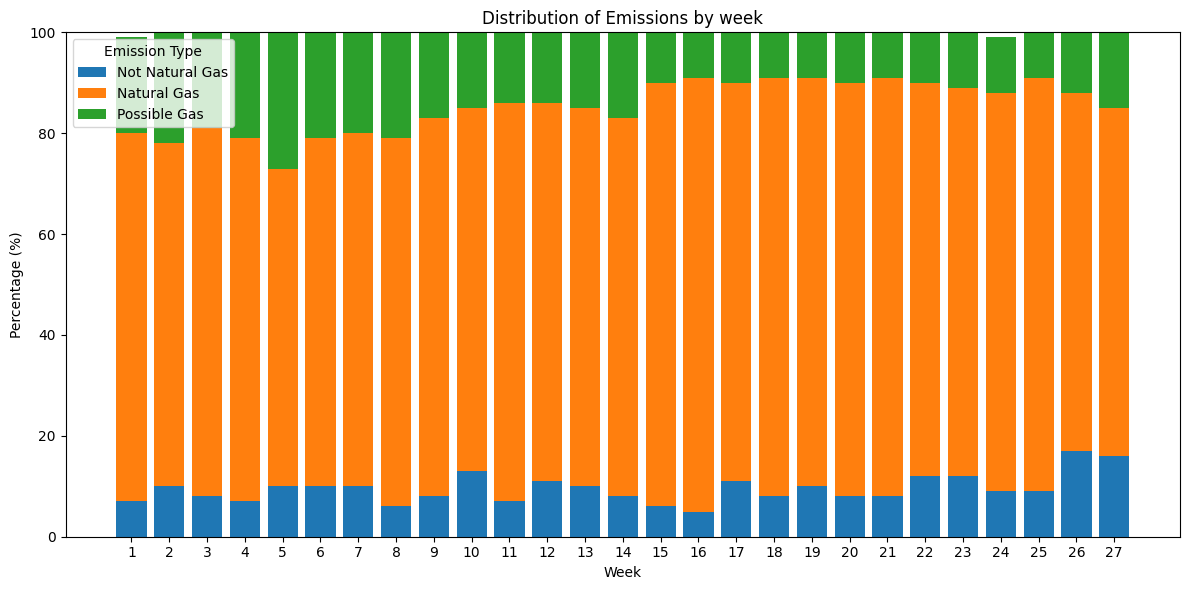

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define the columns corresponding to the Shares
share_columns = ["Not_NGShare","NGShare","PGShare"]

# Ensure all share columns present for consistency; filter to only those present
present_share_columns = [col for col in share_columns if col in export_df.columns]
if not present_share_columns:
    raise ValueError("None of the expected share columns are present in export_df.")

# Prepare data in long format for seaborn
plot_df = export_df.copy()
long_df = plot_df[["ReportWeek"] + present_share_columns].melt(
    id_vars="ReportWeek",
    value_vars=present_share_columns,
    var_name="Share_Type",
    value_name="Value"
)
long_df["Value"] = 100*long_df["Value"].fillna(0)

# Set color mapping for the share types, similar to above
palette_dict = dict(zip(share_columns, ["tab:blue", "tab:orange", "tab:green"]))

plt.figure(figsize=(12, 6))
bottom_vals = pd.Series(0, index=sorted(long_df["ReportWeek"].unique()))

label_dict = {'Not_NGShare':'Not Natural Gas',
              'NGShare':'Natural Gas',
              'PGShare':'Possible Gas'}

for share_type in present_share_columns:
    to_plot = long_df[long_df["Share_Type"] == share_type]
    plt.bar(
        to_plot["ReportWeek"],
        to_plot["Value"],
        bottom=bottom_vals[to_plot["ReportWeek"]].values,
        label=label_dict.get(share_type, share_type),
        color=palette_dict.get(share_type, None)
    )
    bottom_vals[to_plot["ReportWeek"]] += to_plot["Value"].values

plt.xlabel("Week")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Emissions by week")
plt.legend(title="Emission Type")
plt.ylim(0, 100)  # Set y-axis limit between 0 and 1

# Set x-ticks to the week numbers with their labels as week numbers
# Assuming ReportWeek is week number or at least contains week number info
week_numbers = sorted(export_df["ReportWeek"].unique())
plt.xticks(ticks=week_numbers, labels=[str(week) for week in week_numbers])

plt.tight_layout()
plt.show()

### Plotting the B shares

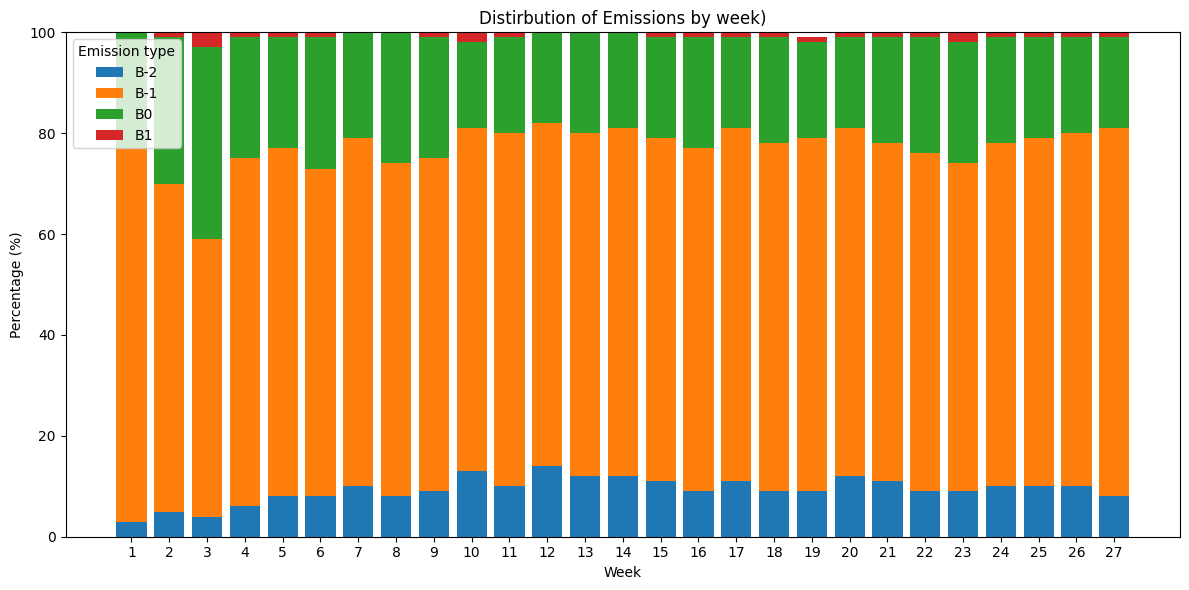

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define the columns corresponding to the 4 B Shares explicitly
b_share_columns = ["B-2Share", "B-1Share", "B0Share", "B1Share"]

# Ensure exactly 4 shares are presented (raise if not all 4 are present)
missing_b_shares = [col for col in b_share_columns if col not in export_df.columns]
if missing_b_shares:
    raise ValueError(f"The following expected B share columns are missing from export_df: {missing_b_shares}")

# Prepare data in long format for seaborn
b_plot_df = export_df.copy()
b_long_df = b_plot_df[["ReportWeek"] + b_share_columns].melt(
    id_vars="ReportWeek",
    value_vars=b_share_columns,
    var_name="B_Share_Type",
    value_name="Value"
)
b_long_df["Value"] =100*b_long_df["Value"].fillna(0)

# Set color mapping for the B share types
b_palette = {
    "B-2Share": "tab:blue",
    "B-1Share": "tab:orange",
    "B0Share": "tab:green",
    "B1Share": "tab:red"
}
b_label = {
    "B-2Share": "B-2",
    "B-1Share": "B-1",
    "B0Share": "B0",
    "B1Share": "B1"
}
plt.figure(figsize=(12, 6))
# Create stacked bar plot via hue
bottom_vals = pd.Series(0, index=sorted(b_long_df["ReportWeek"].unique()))
for b_type in b_share_columns:
    to_plot = b_long_df[b_long_df["B_Share_Type"] == b_type]
    plt.bar(
        to_plot["ReportWeek"], 
        to_plot["Value"], 
        bottom=bottom_vals[to_plot["ReportWeek"]].values,
        label=b_label[b_type], 
        color=b_palette[b_type]
    )
    bottom_vals[to_plot["ReportWeek"]] += to_plot["Value"].values

plt.xlabel("Week")
plt.ylabel("Percentage (%)")
plt.title("Distirbution of Emissions by week)")
plt.legend(title="Emission type")
plt.ylim(0, 100)
# Set x-tick labels as the week numbers (int), not "ReportWeek"
plt.xticks(
    ticks=sorted(b_long_df["ReportWeek"].unique()), 
    labels=[str(int(w)) for w in sorted(b_long_df["ReportWeek"].unique())],
)
plt.tight_layout()
plt.show()

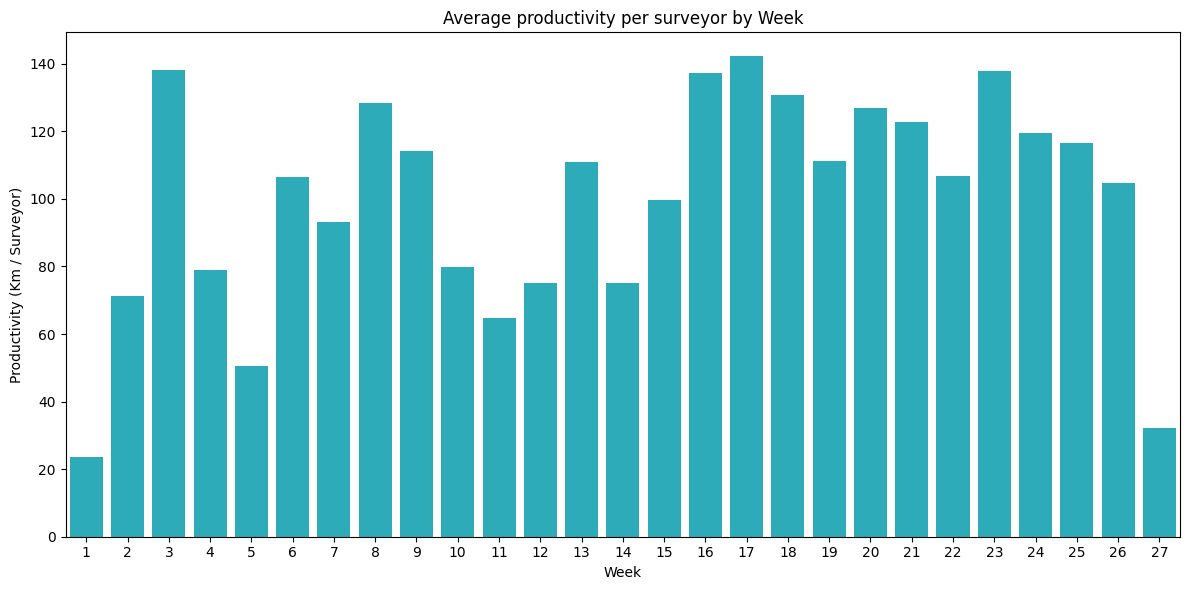

In [24]:
# Plot Productivity per week using seaborn (removed 'ReportWeek' wording)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x="ReportWeek", y="ProductivityPerSurveyor", data=export_df, color='tab:cyan')
plt.title("Average productivity per surveyor by Week")
plt.xlabel("Week")
plt.ylabel("Productivity (Km / Surveyor)")
plt.tight_layout()
plt.show()

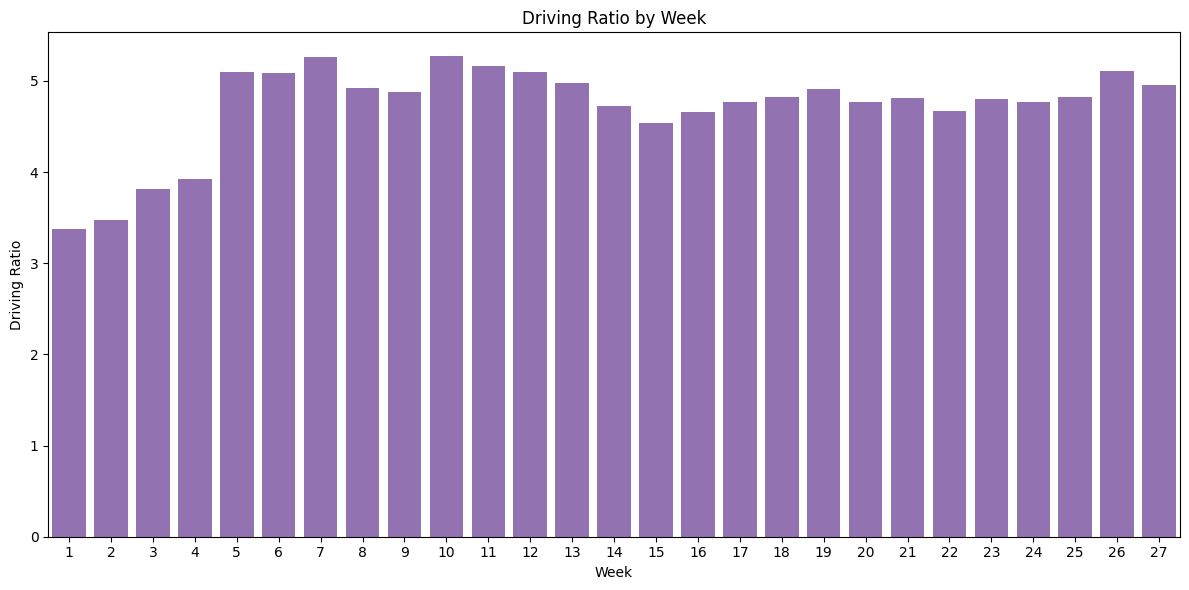

In [25]:
# Plot DrivingRatio as a function of ReportWeek using seaborn

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x="ReportWeek", y="DrivingRatio", data=export_df, color='tab:purple')
plt.title("Driving Ratio by Week")
plt.xlabel("Week")
plt.ylabel("Driving Ratio")
plt.tight_layout()
plt.show()

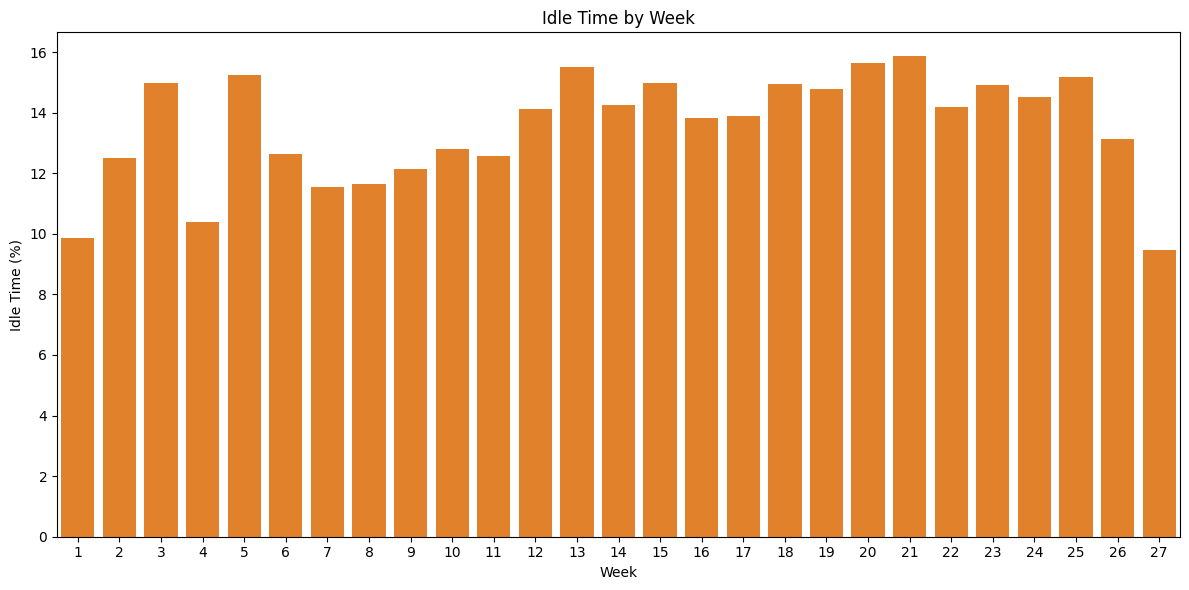

In [26]:
# Plot IdleTime as a function of Week using seaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x="ReportWeek", y="IdleTime", data=export_df, color='tab:orange')
plt.title("Idle Time by Week")
plt.xlabel("Week")
plt.ylabel("Idle Time (%)")
plt.tight_layout()
plt.show()

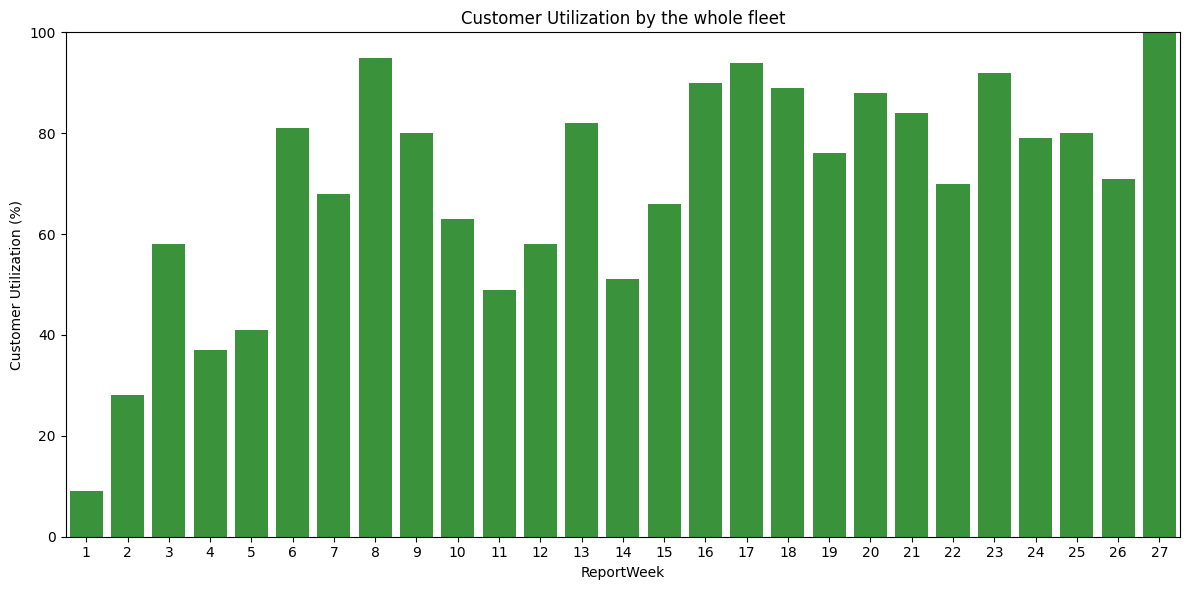

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Normalize CustomerUtilization so the maximum is 100 if possible. 
# (Assume CustomerUtilization is not already out of 100; if already, this will have no effect.)
normalized_util = export_df["CustomerUtilization"] * 100

plt.figure(figsize=(12, 6))
sns.barplot(x="ReportWeek", y=normalized_util, data=export_df, color="tab:green")
plt.title("Customer Utilization by the whole fleet")
plt.xlabel("ReportWeek")
plt.ylabel("Customer Utilization (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [28]:
export_df['InstatanoeusEmission']

0     1.42
1     1.38
2     1.85
3     1.02
4     0.75
5     1.18
6     0.99
7     0.86
8     0.94
9     1.48
10    1.40
11    1.00
12    0.95
13    0.83
14    1.38
15    1.26
16    1.21
17    1.50
18    1.66
19    1.40
20    1.54
21    1.96
22    1.71
23    1.31
24    1.73
25    1.98
26    0.84
Name: InstatanoeusEmission, dtype: float64

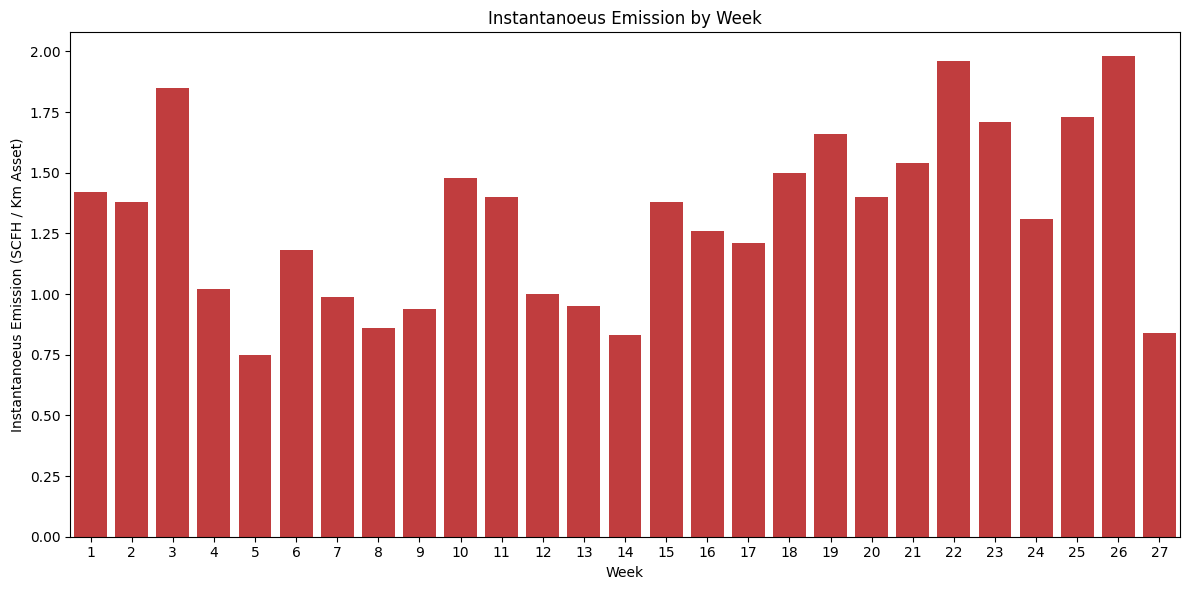

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x="ReportWeek", y="InstatanoeusEmission", data=export_df, color='tab:red')
plt.title("Instantanoeus Emission by Week")
plt.xlabel("Week")
plt.ylabel("Instantanoeus Emission (SCFH / Km Asset)")
plt.tight_layout()
plt.show()

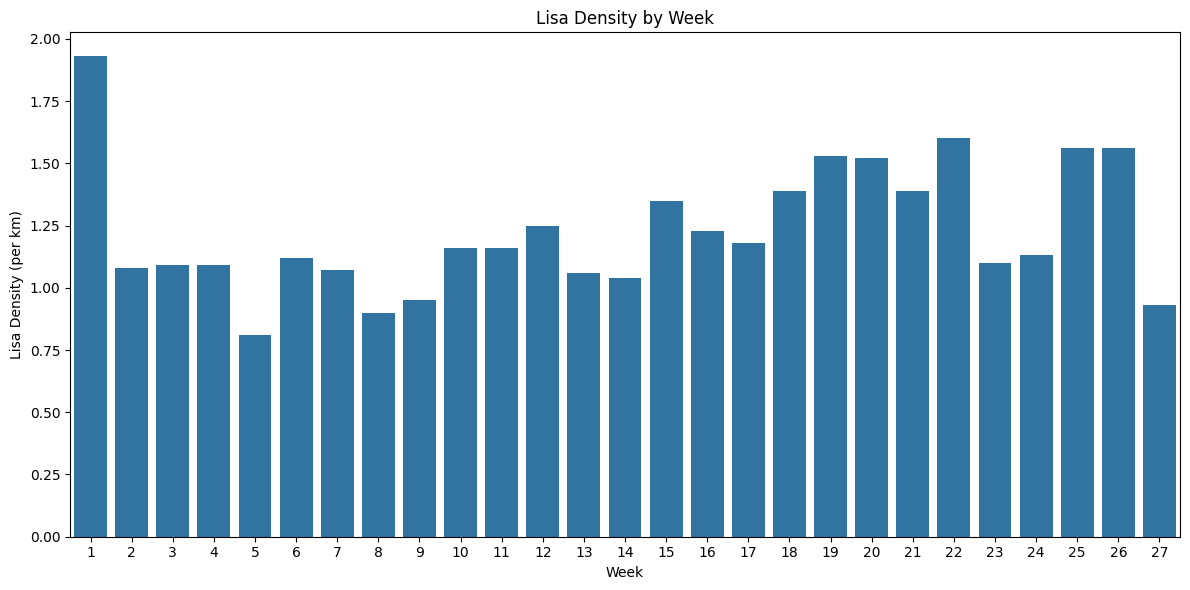

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x="ReportWeek", y="LisaDensity", data=export_df, color='tab:blue')
plt.title("Lisa Density by Week")
plt.xlabel("Week")
plt.ylabel("Lisa Density (per km)")
plt.tight_layout()
plt.show()

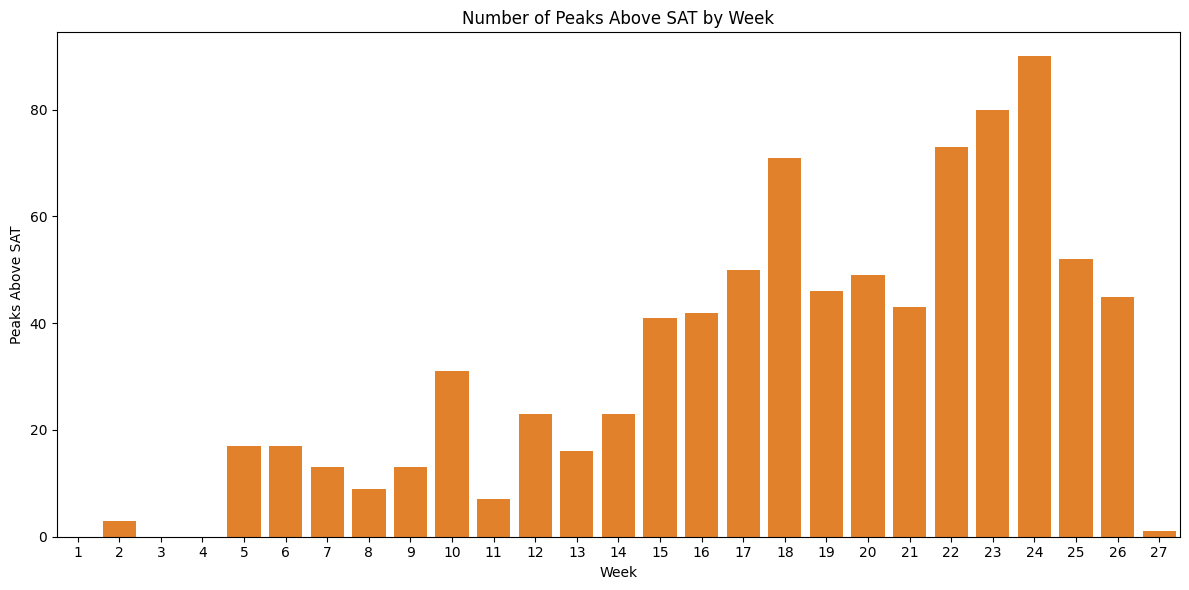

In [31]:
# "peaksaboveSATindication"
# Find and plot (for each week) the number value in "PeakAboveSATCount" (assumed to be numeric, not boolean).
# Assumes export_df has 'ReportWeek' and 'PeakAboveSATCount' as a number field.

import matplotlib.pyplot as plt
import seaborn as sns

# Group by week and sum the counts
peaks_above_sat = (
    export_df.groupby("ReportWeek")["PeakAboveSATCount"]
    .sum()
    .reset_index(name="PeaksAboveSAT")
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x="ReportWeek",
    y="PeaksAboveSAT",
    data=peaks_above_sat,
    color="tab:orange"
)
plt.title("Number of Peaks Above SAT by Week")
plt.xlabel("Week")
plt.ylabel("Peaks Above SAT")
plt.tight_layout()
plt.show()

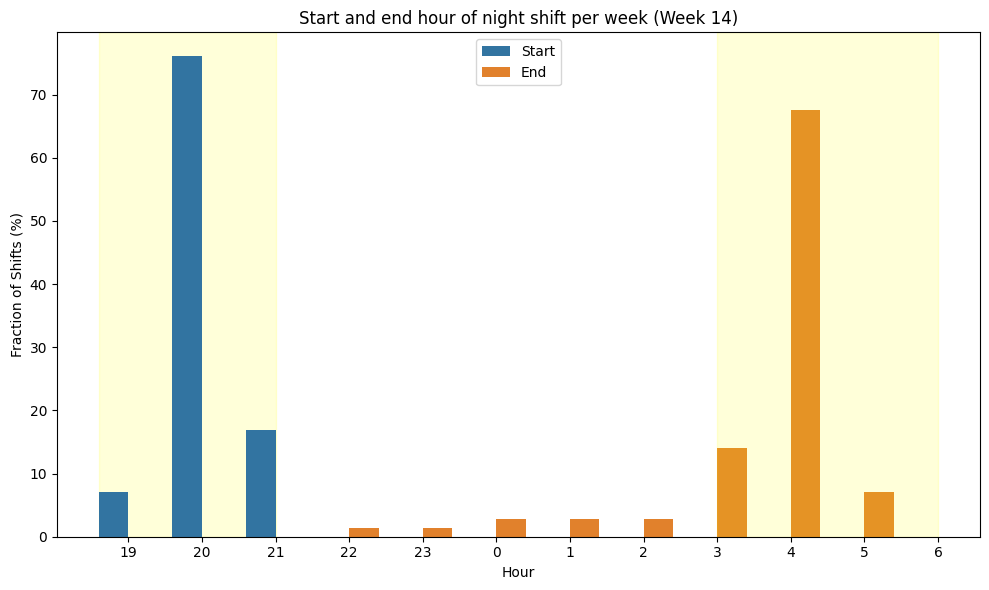

In [32]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import seaborn as sns

# Set bin edges for each hour of the day (0-23)
bins = np.arange(0, 25)  # 0 through 24 for right-inclusive bins
# Rearrange order: from 19,20,...23,0,1,...7 (19 through 23, then 0 through 7)
desired_order = list(range(18, 24)) + list(range(0, 8))

weeks = sorted(time_boundary['Week'].dropna().unique())
# Filter for the current week
week = 14
week_data = time_boundary[time_boundary['Week'] == week]

# Use StartHour and EndHour from week_data to bin per hour and relabel bins as 0, 1, 2, ...
start_hour_counts = pd.cut(
    week_data['StartHour'], bins=bins, right=False, include_lowest=True
).value_counts().sort_index()
start_hour_counts.index = start_hour_counts.index.map(lambda x: x.left)
start_hour_counts.index.name = 'StartHourBin'

end_hour_counts = pd.cut(
    week_data['EndHour'], bins=bins, right=False, include_lowest=True
).value_counts().sort_index()
end_hour_counts.index = end_hour_counts.index.map(lambda x: x.left)
end_hour_counts.index.name = 'EndHourBin'

# Remove bins with zero counts for start and end hours
nonzero_start_hour_counts = start_hour_counts[start_hour_counts > 0]
nonzero_end_hour_counts = end_hour_counts[end_hour_counts > 0]

# Normalize by the total number of start hour counts
total_start_hour_count = nonzero_start_hour_counts.sum()
norm_start_hour_counts = 100* nonzero_start_hour_counts / total_start_hour_count
norm_end_hour_counts = 100 *nonzero_end_hour_counts / total_start_hour_count

# Rearrange for plotting
reordered_start_hour_counts = norm_start_hour_counts.reindex(
    [h for h in desired_order if h in norm_start_hour_counts.index]
)
reordered_end_hour_counts = norm_end_hour_counts.reindex(
    [h for h in desired_order if h in norm_end_hour_counts.index]
)

# Prepare DataFrame for Seaborn "melted" barplot
df_plot = pd.DataFrame({
    "Hour": [*reordered_start_hour_counts.index, *reordered_end_hour_counts.index],
    "Count": [*reordered_start_hour_counts.values, *reordered_end_hour_counts.values],
    "Type": (["Start"] * len(reordered_start_hour_counts)) + (["End"] * len(reordered_end_hour_counts)),
})
# Preserve plotting order as categorical
df_plot["Hour"] = pd.Categorical(df_plot["Hour"], categories=desired_order, ordered=True) 

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x="Hour", y="Count", hue="Type")
plt.xlabel("Hour")
plt.ylabel("Fraction of Shifts (%)")  # Update y-label to clarify normalization
plt.title(f"Start and end hour of night shift per week (Week {week})")

# Draw vertical line at hour 19
# Shade the region between hours 3 and 6 and between 19-21 for optimal periods
plt.axvspan(desired_order.index(3), desired_order.index(6), color='yellow', alpha=0.15)
plt.axvspan(desired_order.index(19) - 0.4, desired_order.index(21), color='yellow', alpha=0.15, zorder=0)

plt.tight_layout()
plt.legend()

#### Distribution of wind speeds

To be done

#### Distribution of car speeds

In [33]:
max_speed = 80
def survey_binning(df):
    # Bin avg speed in steps of 5 km/h
    bins = np.arange(0, max_speed + 5, 5)
    binned = pd.cut(df['AvgSpeedKm'], bins=bins)
    return binned.value_counts().sort_index()

binned_speeds = report_summary_agg.groupby(aggregator).apply(survey_binning)

from matplotlib.backends.backend_pdf import PdfPages

pdf_file = "output/binned_speeds_by_week.pdf"
with PdfPages(pdf_file) as pdf:
    # Iterate directly over the rows and plot
    for idx, (week_key, row) in enumerate(binned_speeds.iterrows()):
        fig, ax = plt.subplots(figsize=(12,5))
        row.plot(
            kind='bar',
            ax=ax,
        )
        ax.set_title(f"Binned Avg Speeds for {week_key}")
        ax.set_xlabel("Avg Speed (km/h bin)")
        ax.set_ylabel("Surveys")
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)
    print(f"Saved binned average car speeds for {len(binned_speeds)} weeks to '{pdf_file}'")
binned_speeds.to_excel("output/binned_speeds.xlsx")

Saved binned average car speeds for 27 weeks to 'output/binned_speeds_by_week.pdf'
